# DATASCI 207 — ETF Volatility Dataset: Time-Series EDA

**Goal:** Provide a comprehensive, time-series-appropriate EDA notebook for the wrangled ETF volatility panel (`ticker × date`) with macro/risk features.

**What this notebook emphasizes**
- Panel integrity: unique `(ticker, date)`, consistent date parsing, monotone time ordering
- Time-series EDA: coverage/gaps, distributions, regimes, autocorrelation, cross-sectional behavior
- **Leakage/label alignment checks**: recompute log returns, trailing realized volatility, and forward realized volatility label
- Baselines to beat: persistence baselines using trailing volatility

> **Tip:** Run top-to-bottom once. Then rerun just the sections you tweak (paths, ticker selection, cutoffs).


In [4]:
# Purpose:
# - Import core libraries used throughout the notebook.
# - Keep dependencies light; optional sections (seaborn/statsmodels) degrade gracefully.

import os
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Optional: nicer plots + correlation heatmaps
try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

# Optional: ACF/PACF style diagnostics
try:
    from statsmodels.tsa.stattools import acf
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

print("seaborn:", HAS_SEABORN, "| statsmodels:", HAS_STATSMODELS)

seaborn: True | statsmodels: True


## 1) Configuration

Set your input path(s) here.  
- **CSV** is easiest (portable).  
- **Parquet** is fastest and preserves dtypes (if you have `pyarrow` installed).

If you are in **Colab + Drive**, typical paths look like:
- `/content/drive/MyDrive/Colab Notebooks/vol_dataset_post_wrangle_021026.csv`


In [5]:
# Mount drive

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Purpose:
# - Centralize all settings in one place.

# ---- Input paths (edit as needed) ----
DATA_PATH_CSV = r"/content/drive/MyDrive/Colab Notebooks/vol_dataset_post_wrangle_021026.csv"   # <-- change if needed
DATA_PATH_PARQUET = None  # e.g., r"/content/drive/MyDrive/Colab Notebooks/vol_dataset_post_wrangle_021026.parquet"

USE_INPUT = "csv"   # "csv" or "parquet"

# ---- Key columns ----
KEY_COLS = ["ticker", "date"]
DATE_COL = "date"
TICKER_COL = "ticker"

# ---- Core financial columns ----
PRICE_COL = "adj_close"
VOLUME_COL = "volume"
RETURN_COL = "daily_log_return"

# ---- Target (label) ----
TARGET_COL = "forward_vol_5d_annual_decimel_calculated"

# ---- Volatility feature columns (if present) ----
TRAILING_VOL_COLS = [
    "trailing_vol_annual_decimel_5d_calculated",
    "trailing_vol_annual_decimel_20d_calculated",
    "trailing_vol_annual_decimel_5d_factset",
    "trailing_vol_annual_decimel_20d_factset",
]

# ---- Macro / risk feature columns (wide) ----
MACRO_COLS = [
    "US_3M_TB_YLD",
    "US_10Y_BOND_YLD",
    "NYGOLDS",
    "OIL_WTI_S",
    "VIX",
]

# ---- EDA choices ----
EDA_SAMPLE_TICKER = "SPY"
BIG_GAP_DAYS = 10   # flag gaps larger than this many calendar days inside a ticker
ANNUALIZATION = 252

# ---- Time-split defaults (edit for your project) ----
TRAIN_END = "2022-12-31"
VAL_END   = "2024-12-31"   # test = after VAL_END

# ---- Output ----
OUTPUT_DIR = r"/content/drive/MyDrive/Colab Notebooks/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2) Load dataset + parse dates + canonical sort

In [7]:
# Purpose:
# - Load the panel dataset (CSV or Parquet).
# - Convert DATE_COL to datetime.
# - Canonical sort: ticker ascending, date ascending (oldest → newest).

def load_dataset():
    if USE_INPUT.lower() == "csv":
        assert DATA_PATH_CSV is not None, "Set DATA_PATH_CSV"
        df_raw = pd.read_csv(DATA_PATH_CSV)
    elif USE_INPUT.lower() == "parquet":
        assert DATA_PATH_PARQUET is not None, "Set DATA_PATH_PARQUET"
        df_raw = pd.read_parquet(DATA_PATH_PARQUET)
    else:
        raise ValueError("USE_INPUT must be 'csv' or 'parquet'")
    return df_raw

df_raw = load_dataset()

print("Loaded shape:", df_raw.shape)
print("Columns:", len(df_raw.columns))

df = df_raw.copy()

# Parse dates robustly
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

# Fail-fast if parsing broke
bad_dates = df[DATE_COL].isna().sum()
print("Bad date parses:", bad_dates)
assert bad_dates == 0, "Some dates failed to parse. Inspect df[df[DATE_COL].isna()]."

# Canonical sort for all time-series operations
df = df.sort_values([TICKER_COL, DATE_COL], ascending=[True, True]).reset_index(drop=True)

print("Date range:", df[DATE_COL].min().date(), "→", df[DATE_COL].max().date())
df.head()


Loaded shape: (96525, 23)
Columns: 23
Bad date parses: 0
Date range: 2014-12-31 → 2025-12-31


,date,ticker,adj_close,has_price,volume_k,volume,trailing_vol_daily_pct_5d_factset,trailing_vol_daily_pct_20d_factset,trailing_vol_annual_decimel_5d_factset,trailing_vol_annual_decimel_20d_factset,...,group_type,market,sector,industry,daily_log_return,NYGOLDS,OIL_WTI_S,US_10Y_BOND_YLD,US_3M_TB_YLD,VIX
0,2021-04-21,BEDZ,24.95,1.0,84.476,84476.0,1.5753,1.5827,0.2501,0.2512,...,industry,NaN,NaN,hotels_resorts_cruise_lines,NaN,1793.6,61.34,1.56,0.03,17.50
1,2021-04-22,BEDZ,25.05,1.0,15.443,15443.0,1.5753,1.5827,0.2501,0.2512,...,industry,NaN,NaN,hotels_resorts_cruise_lines,0.004048,1783.9,61.45,1.56,0.03,18.71
2,2021-04-23,BEDZ,25.32,1.0,11.732,11732.0,1.5760,1.5833,0.2502,0.2513,...,industry,NaN,NaN,hotels_resorts_cruise_lines,0.010682,1776.9,62.18,1.56,0.02,17.33
3,2021-04-26,BEDZ,25.43,1.0,33.758,33758.0,1.5764,1.5837,0.2502,0.2514,...,industry,NaN,NaN,hotels_resorts_cruise_lines,0.004343,1781.0,62.02,1.57,0.02,17.64
4,2021-04-27,BEDZ,25.64,1.0,29.076,29076.0,1.5770,1.5843,0.2503,0.2515,...,industry,NaN,NaN,hotels_resorts_cruise_lines,0.008268,1775.8,63.03,1.62,0.01,17.56


## 3) Panel integrity checks (keys, duplicates, monotone dates, coverage)

In [8]:
# Purpose:
# - Validate unique (ticker, date).
# - Check monotone dates within each ticker.
# - Summarize coverage.

# Duplicate key check
dup_count = df.duplicated(KEY_COLS).sum()
print("Duplicate (ticker,date) rows:", int(dup_count))

# Monotone date check within ticker
def count_non_monotone_dates(d):
    # d is already sorted by (ticker,date) globally, but verify per ticker
    return (~d.groupby(TICKER_COL)[DATE_COL].apply(lambda s: s.is_monotonic_increasing)).sum()

non_mono = int(count_non_monotone_dates(df))
print("Tickers with non-monotone dates:", non_mono)

# Coverage per ticker
coverage = (
    df.groupby(TICKER_COL)[DATE_COL]
      .agg(start="min", end="max", n_days="count")
      .sort_values("n_days", ascending=False)
)

print("Number of tickers:", coverage.shape[0])
display(coverage.head(10))
display(coverage.tail(10))


Duplicate (ticker,date) rows: 0
Tickers with non-monotone dates: 0
Number of tickers: 36


,start,end,n_days
ticker,,,
KBE,2014-12-31,2025-12-31,2767
IYZ,2014-12-31,2025-12-31,2767
KIE,2014-12-31,2025-12-31,2767
KCE,2014-12-31,2025-12-31,2767
XSD,2014-12-31,2025-12-31,2767
XME,2014-12-31,2025-12-31,2767
KRE,2014-12-31,2025-12-31,2767
PEJ,2014-12-31,2025-12-31,2767
PNQI,2014-12-31,2025-12-31,2767


,start,end,n_days
ticker,,,
XLV,2014-12-31,2025-12-31,2767
XLY,2014-12-31,2025-12-31,2767
XTN,2014-12-31,2025-12-31,2767
XPH,2014-12-31,2025-12-31,2767
XOP,2014-12-31,2025-12-31,2767
VGT,2015-01-02,2025-12-31,2766
XLRE,2015-10-08,2025-12-31,2573
FTXG,2016-09-21,2025-12-31,2333
XLC,2018-06-19,2025-12-31,1895


## 4) Gaps and missingness (time continuity + feature missing rates)

In [9]:
# Purpose:
# - Identify big gaps in each ticker's date sequence (calendar-day gaps).
# - Summarize missingness by column and by ticker.

# Big gaps detection (calendar days)
tmp = df[[TICKER_COL, DATE_COL]].copy()
tmp["prev_date"] = tmp.groupby(TICKER_COL)[DATE_COL].shift(1)
tmp["gap_days"] = (tmp[DATE_COL] - tmp["prev_date"]).dt.days

big_gaps = tmp[tmp["gap_days"] > BIG_GAP_DAYS].copy()
print("Big gaps (gap_days >", BIG_GAP_DAYS, "):", big_gaps.shape[0])
display(big_gaps.head(20))

# Missingness by column
miss = df.isna().mean().sort_values(ascending=False)
miss_tbl = pd.DataFrame({"missing_rate": miss, "missing_count": df.isna().sum()})
display(miss_tbl.head(15))

# Missingness by ticker for the target (often informative)
if TARGET_COL in df.columns:
    tgt_miss_by_ticker = df.groupby(TICKER_COL)[TARGET_COL].apply(lambda s: s.isna().mean()).sort_values(ascending=False)
    display(tgt_miss_by_ticker.head(10))


Big gaps (gap_days > 10 ): 0


,ticker,date,prev_date,gap_days


,missing_rate,missing_count
NYGOLDS,0.000000,0
OIL_WTI_S,0.000000,0
US_10Y_BOND_YLD,0.000000,0
US_3M_TB_YLD,0.000000,0
VIX,0.000000,0
adj_close,0.000000,0
daily_log_return,0.000373,36
date,0.000000,0
forward_vol_5d_annual_decimel_calculated,0.001865,180
group_type,0.000000,0


,forward_vol_5d_annual_decimel_calculated
ticker,
BEDZ,0.004234
XLC,0.002639
FTXG,0.002143
XLRE,0.001943
VGT,0.001808
IYZ,0.001807
KBE,0.001807
KRE,0.001807
PEJ,0.001807


## 5) Macro feature sanity (should be constant across tickers on a given date)

In [10]:
# Purpose:
# - On any given date, macro columns should not vary by ticker (they are shared market series).
# - We test this by counting unique values per date for each macro column.

present_macro = [c for c in MACRO_COLS if c in df.columns]
print("Macro columns present:", present_macro)

macro_uniques = {}
for c in present_macro:
    # number of unique values across tickers for each date
    nun = df.groupby(DATE_COL)[c].nunique(dropna=False)
    macro_uniques[c] = {
        "median_unique_per_date": float(nun.median()),
        "max_unique_per_date": int(nun.max()),
        "pct_dates_unique_gt_1": float((nun > 1).mean()),
    }

macro_check = pd.DataFrame(macro_uniques).T.sort_values("pct_dates_unique_gt_1", ascending=False)
display(macro_check)

# Interpretation:
# - Ideally: median_unique_per_date == 1 and pct_dates_unique_gt_1 == 0


Macro columns present: ['US_3M_TB_YLD', 'US_10Y_BOND_YLD', 'NYGOLDS', 'OIL_WTI_S', 'VIX']


,median_unique_per_date,max_unique_per_date,pct_dates_unique_gt_1
US_3M_TB_YLD,1.0,1.0,0.0
US_10Y_BOND_YLD,1.0,1.0,0.0
NYGOLDS,1.0,1.0,0.0
OIL_WTI_S,1.0,1.0,0.0
VIX,1.0,1.0,0.0


## 6) Distribution EDA (returns, volume, trailing vol, target vol)

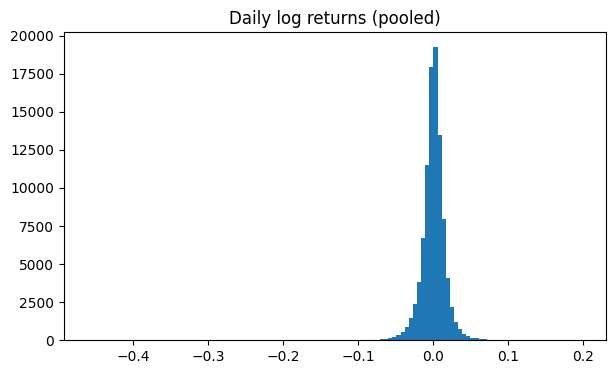

count    96489.000000
mean         0.000290
std          0.016145
min         -0.459984
1%          -0.044887
5%          -0.024899
50%          0.000772
95%          0.023346
99%          0.042107
max          0.197543
Name: daily_log_return, dtype: float64


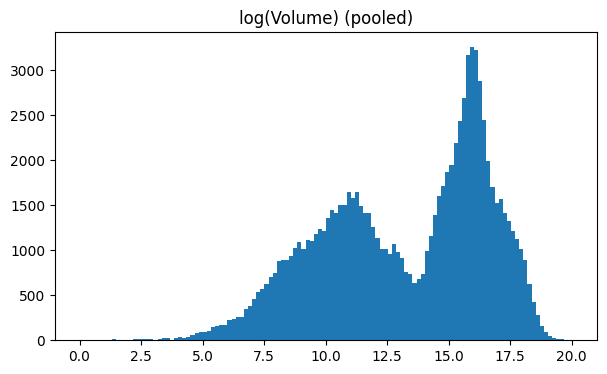

count    9.597800e+04
mean     9.397789e+06
std      2.049194e+07
min      1.000000e+00
1%       2.690000e+02
5%       1.915000e+03
50%      1.328570e+06
95%      4.827411e+07
99%      9.794572e+07
max      5.072443e+08
Name: volume, dtype: float64


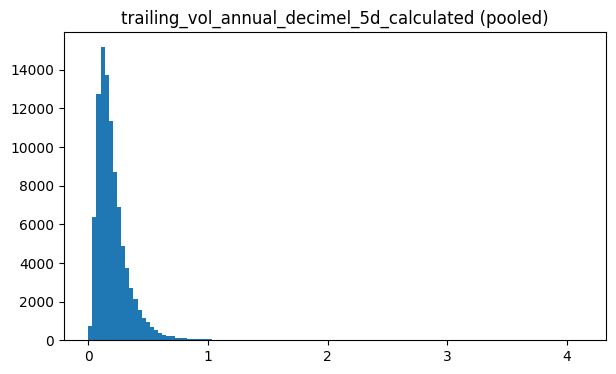

trailing_vol_annual_decimel_5d_calculated {'count': 96345.0, 'mean': 0.2069985458508485, 'std': 0.15347008081123947, 'min': 0.0, '1%': 0.0371, '5%': 0.0601, '50%': 0.1701, '95%': 0.4669, '99%': 0.7661039999999979, 'max': 4.1207}


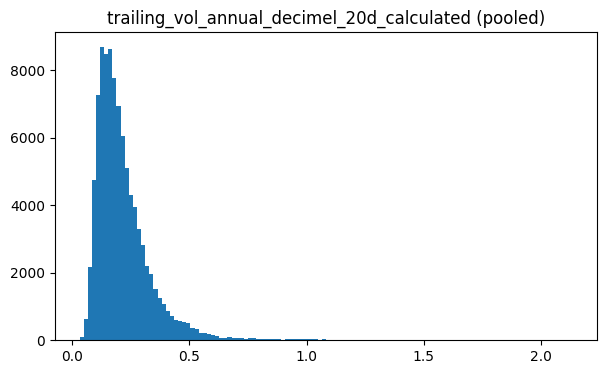

trailing_vol_annual_decimel_20d_calculated {'count': 95805.0, 'mean': 0.2201050028704138, 'std': 0.1324635772389395, 'min': 0.0319, '1%': 0.0699, '5%': 0.0931, '50%': 0.1882, '95%': 0.4478, '99%': 0.7391800000000032, 'max': 2.1347}


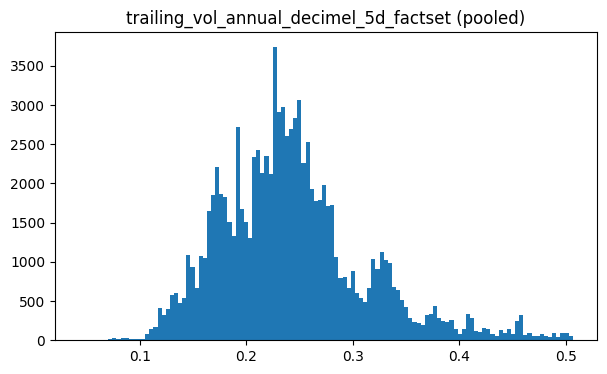

trailing_vol_annual_decimel_5d_factset {'count': 96525.0, 'mean': 0.24293003367003368, 'std': 0.06871785874580691, 'min': 0.0435, '1%': 0.1203, '5%': 0.1472, '50%': 0.2351, '95%': 0.3761, '99%': 0.4582, 'max': 0.5063}


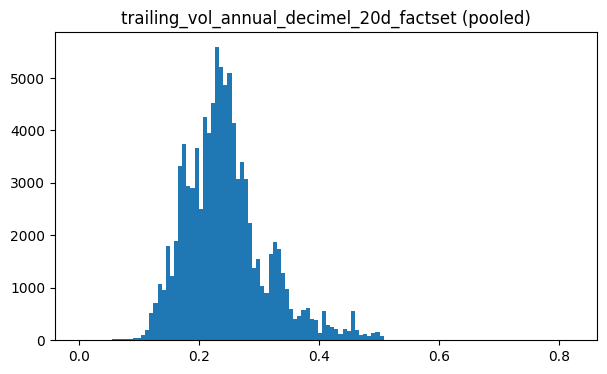

trailing_vol_annual_decimel_20d_factset {'count': 96489.0, 'mean': 0.24402550549803598, 'std': 0.06884942270723506, 'min': 0.0001, '1%': 0.1215, '5%': 0.1481, '50%': 0.2359, '95%': 0.3774, '99%': 0.4589, 'max': 0.8234}


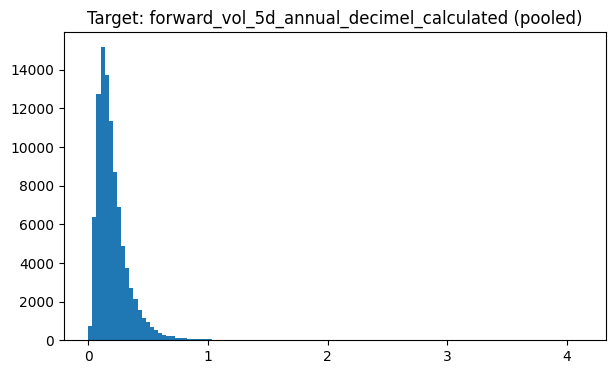

count    96345.000000
mean         0.206999
std          0.153470
min          0.000000
1%           0.037100
5%           0.060100
50%          0.170100
95%          0.466900
99%          0.766104
max          4.120700
Name: forward_vol_5d_annual_decimel_calculated, dtype: float64


In [11]:
# Purpose:
# - Visualize distributions: returns, log(volume), target vol, trailing vol.
# - This gives you tail behavior, skew, and scaling needs.

def safe_hist(series, title, bins=100):
    s = series.dropna()
    plt.figure(figsize=(7,4))
    plt.hist(s, bins=bins)
    plt.title(title)
    plt.show()

# Returns
if RETURN_COL in df.columns:
    safe_hist(df[RETURN_COL], "Daily log returns (pooled)", bins=120)
    print(df[RETURN_COL].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]))

# Volume
if VOLUME_COL in df.columns:
    vol = df[VOLUME_COL].replace(0, np.nan)
    safe_hist(np.log(vol), "log(Volume) (pooled)", bins=120)
    print(vol.describe(percentiles=[0.01,0.05,0.5,0.95,0.99]))

# Trailing vol examples
for c in [x for x in TRAILING_VOL_COLS if x in df.columns]:
    safe_hist(df[c], f"{c} (pooled)", bins=120)
    print(c, df[c].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]).to_dict())

# Target
if TARGET_COL in df.columns:
    safe_hist(df[TARGET_COL], f"Target: {TARGET_COL} (pooled)", bins=120)
    print(df[TARGET_COL].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]))


## 7) Time-series plots for one ticker (price, returns, trailing vol, forward vol)

Ticker: SPY | rows: 2767 | range: 2014-12-31 → 2025-12-31


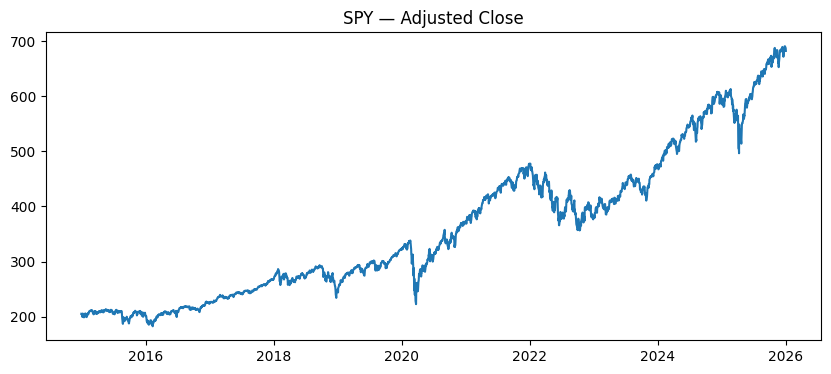

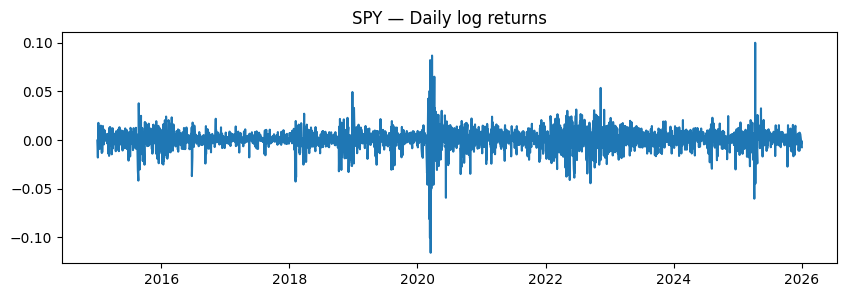

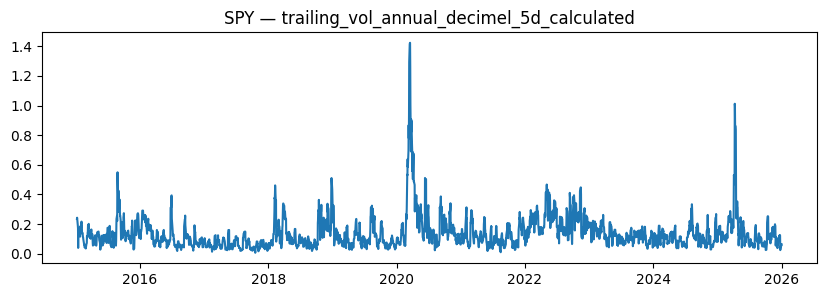

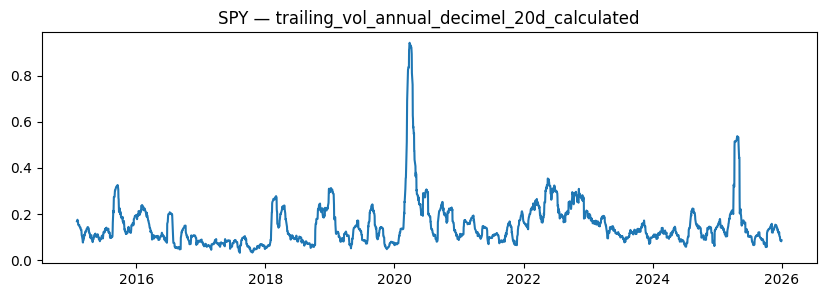

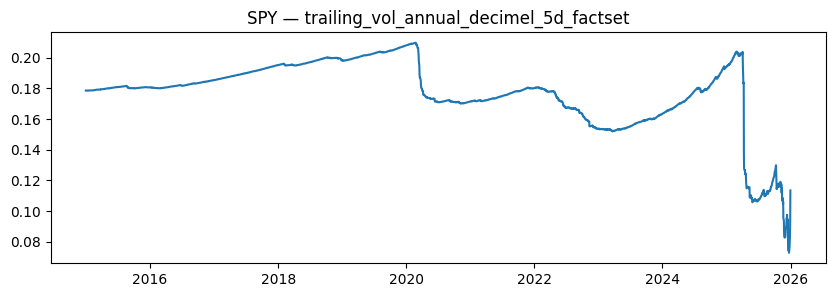

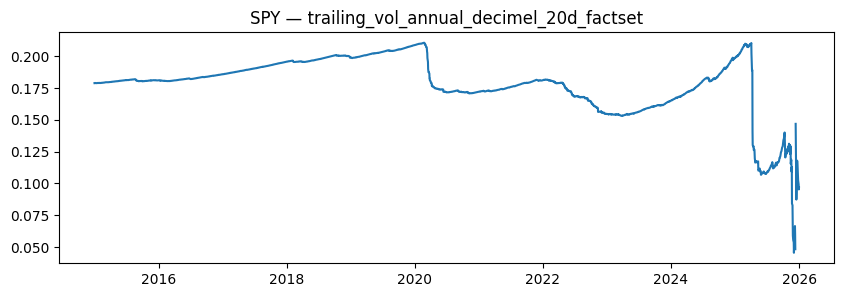

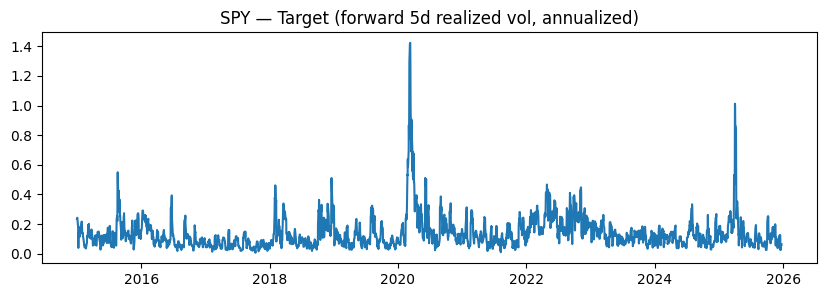

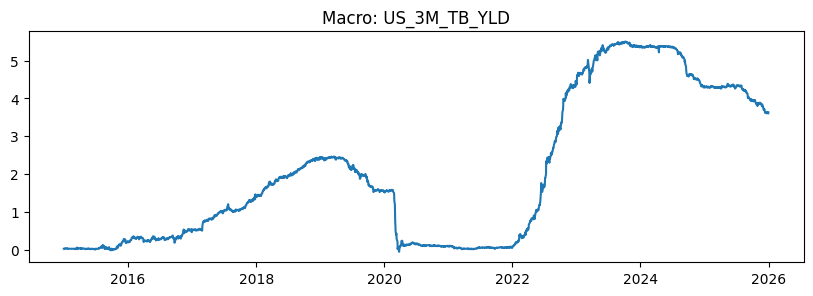

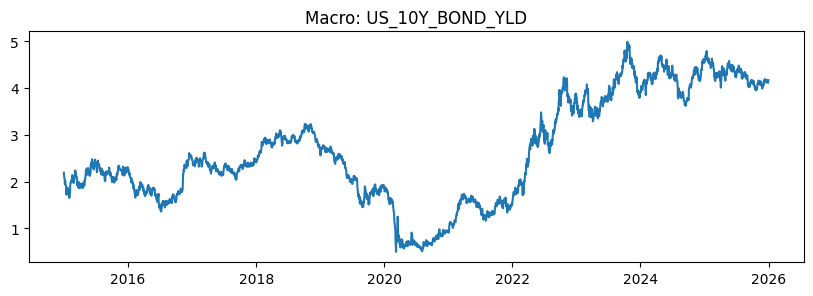

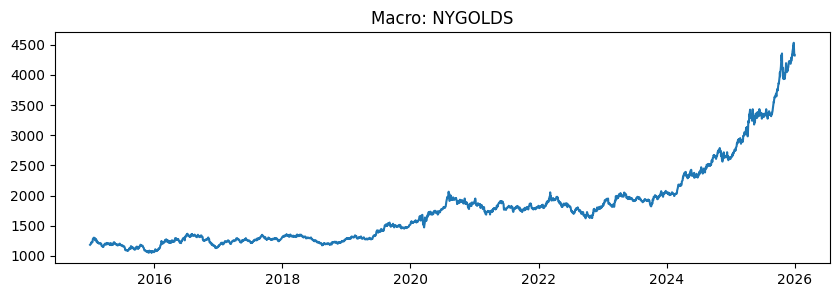

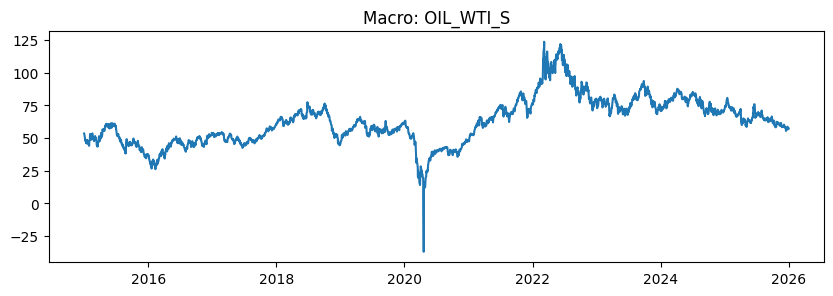

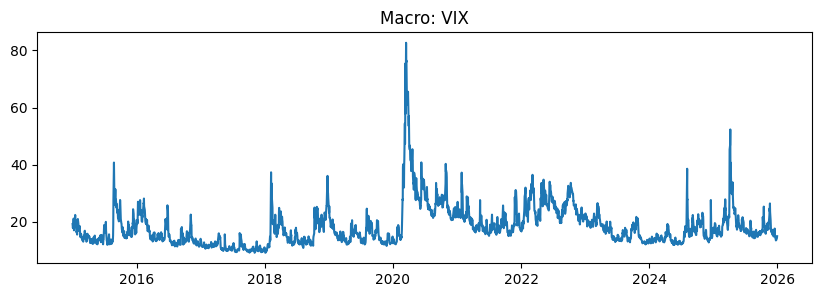

In [ ]:
# Purpose:
# - Plot core series for a representative ticker.
# - Reveals volatility clustering and regime shifts.

ticker = EDA_SAMPLE_TICKER
d = df[df[TICKER_COL] == ticker].copy()

print("Ticker:", ticker, "| rows:", d.shape[0], "| range:", d[DATE_COL].min().date(), "→", d[DATE_COL].max().date())

# Price
if PRICE_COL in d.columns:
    plt.figure(figsize=(10,4))
    plt.plot(d[DATE_COL], d[PRICE_COL])
    plt.title(f"{ticker} — Adjusted Close")
    plt.show()

# Returns
if RETURN_COL in d.columns:
    plt.figure(figsize=(10,3))
    plt.plot(d[DATE_COL], d[RETURN_COL])
    plt.title(f"{ticker} — Daily log returns")
    plt.show()

# Trailing vol
for c in [x for x in TRAILING_VOL_COLS if x in d.columns]:
    plt.figure(figsize=(10,3))
    plt.plot(d[DATE_COL], d[c])
    plt.title(f"{ticker} — {c}")
    plt.show()

# Target forward vol
if TARGET_COL in d.columns:
    plt.figure(figsize=(10,3))
    plt.plot(d[DATE_COL], d[TARGET_COL])
    plt.title(f"{ticker} — Target (forward 5d realized vol, annualized)")
    plt.show()

# Macro series overlay (optional)
present_macro = [c for c in MACRO_COLS if c in d.columns]
for c in present_macro:
    plt.figure(figsize=(10,3))
    plt.plot(d[DATE_COL], d[c])
    plt.title(f"Macro: {c}")
    plt.show()


## 8) Autocorrelation diagnostics (returns vs squared returns vs volatility)

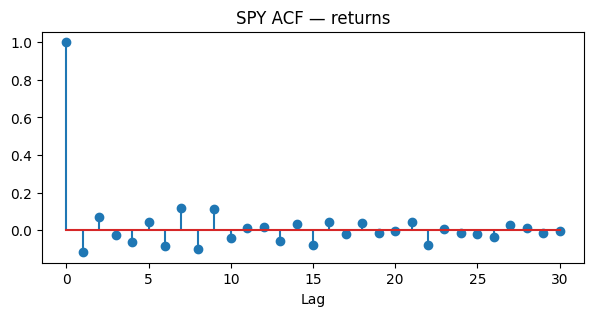

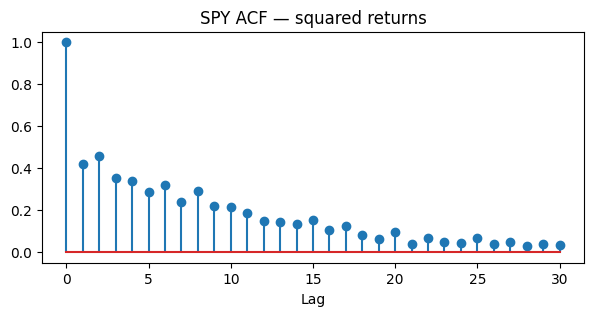

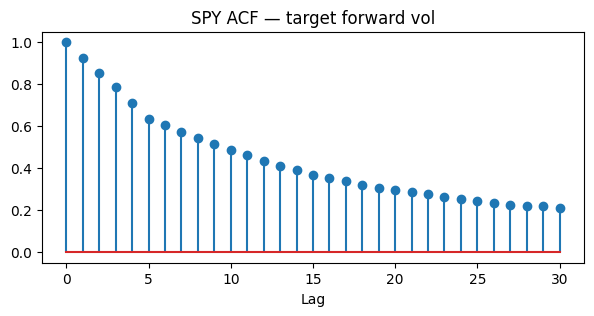

In [ ]:
# Purpose:
# - Check autocorrelation structure.
# - Returns typically have low ACF; squared returns / vol often have stronger ACF (volatility clustering).

ticker = EDA_SAMPLE_TICKER
d = df[df[TICKER_COL] == ticker].copy()

if RETURN_COL not in d.columns:
    print("No RETURN_COL found; skipping ACF.")
else:
    r = d[RETURN_COL].dropna().values
    r2 = (d[RETURN_COL]**2).dropna().values

    def plot_acf_like(x, nlags=30, title="ACF"):
        if HAS_STATSMODELS:
            vals = acf(x, nlags=nlags, fft=True)
        else:
            # simple autocorr estimate
            vals = [1.0] + [np.corrcoef(x[:-k], x[k:])[0,1] for k in range(1, nlags+1)]
            vals = np.array(vals)
        plt.figure(figsize=(7,3))
        # Removed 'use_line_collection=True' as it's no longer supported by matplotlib.stem()
        plt.stem(range(len(vals)), vals)
        plt.title(title)
        plt.xlabel("Lag")
        plt.show()

    plot_acf_like(r, nlags=30, title=f"{ticker} ACF — returns")
    plot_acf_like(r2, nlags=30, title=f"{ticker} ACF — squared returns")

    if TARGET_COL in d.columns:
        y = d[TARGET_COL].dropna().values
        plot_acf_like(y, nlags=30, title=f"{ticker} ACF — target forward vol")


## 9) Feature–target relationships (scatter + correlations)

Train rows: 69453 | Train end: 2022-12-31
Candidate feature columns: ['trailing_vol_annual_decimel_5d_calculated', 'trailing_vol_annual_decimel_20d_calculated', 'trailing_vol_annual_decimel_5d_factset', 'trailing_vol_annual_decimel_20d_factset', 'US_3M_TB_YLD', 'US_10Y_BOND_YLD', 'NYGOLDS', 'OIL_WTI_S', 'VIX']


,forward_vol_5d_annual_decimel_calculated
forward_vol_5d_annual_decimel_calculated,1.000000
trailing_vol_annual_decimel_20d_calculated,0.642738
trailing_vol_annual_decimel_5d_calculated,0.636462
VIX,0.591595
trailing_vol_annual_decimel_20d_factset,0.330381
trailing_vol_annual_decimel_5d_factset,0.329740
NYGOLDS,0.227679
OIL_WTI_S,-0.017132
US_3M_TB_YLD,-0.041820
US_10Y_BOND_YLD,-0.128753


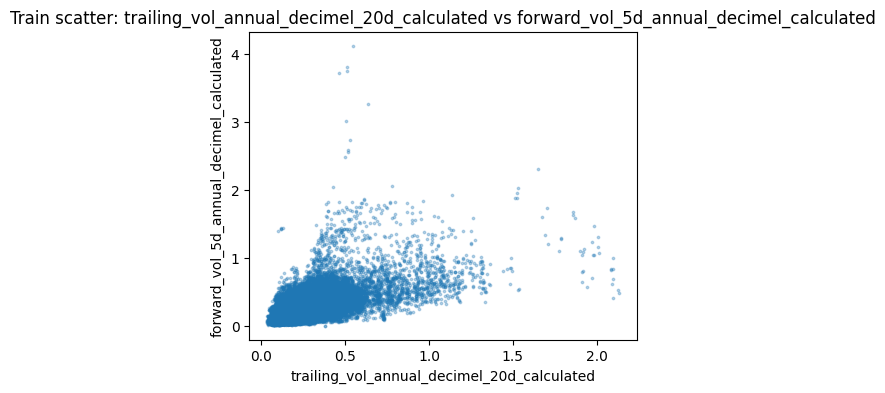

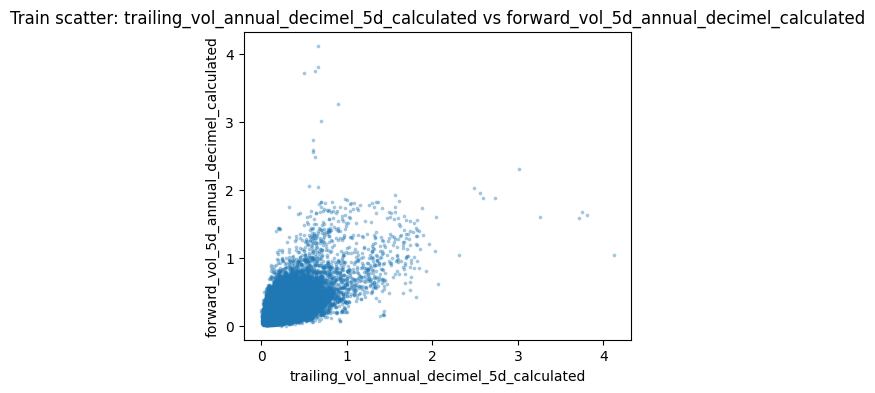

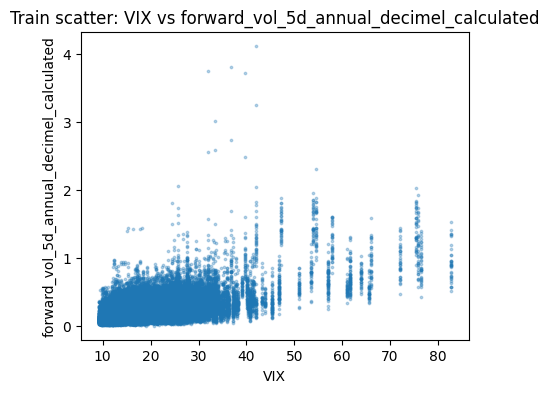

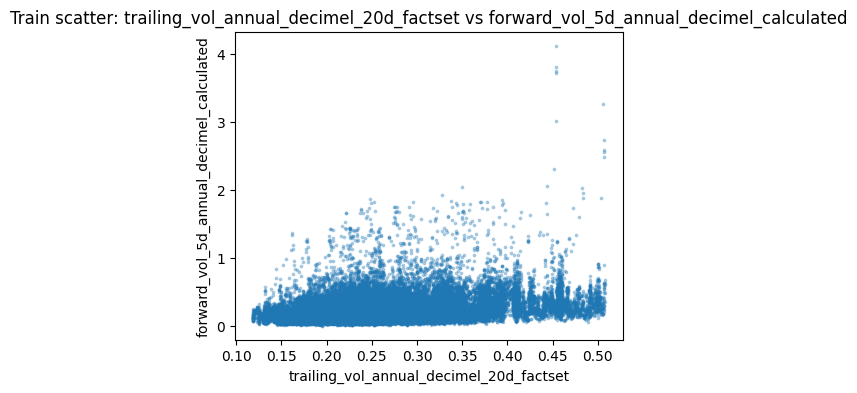

In [ ]:
# Purpose:
# - Check whether common predictors (trailing vol, macro) relate to the target.
# - Use training window only to avoid peeking at future performance.

# Create a train mask (time-based)
train_mask = df[DATE_COL] <= pd.to_datetime(TRAIN_END)

df_train = df.loc[train_mask].copy()
print("Train rows:", df_train.shape[0], "| Train end:", TRAIN_END)

# Candidate features: trailing vols + macro
feature_cols = [c for c in TRAILING_VOL_COLS + MACRO_COLS if c in df_train.columns]
feature_cols = [c for c in feature_cols if c != TARGET_COL]

print("Candidate feature columns:", feature_cols)

if TARGET_COL in df_train.columns:
    # Correlation table (numeric only)
    corr_cols = [TARGET_COL] + feature_cols
    corr_df = df_train[corr_cols].corr(numeric_only=True)[[TARGET_COL]].sort_values(TARGET_COL, ascending=False)
    display(corr_df)

    # Scatter plots for the most important few
    top_feats = corr_df.index.tolist()[1:5]  # exclude TARGET itself
    for c in top_feats:
        plt.figure(figsize=(5,4))
        plt.scatter(df_train[c], df_train[TARGET_COL], s=3, alpha=0.3)
        plt.title(f"Train scatter: {c} vs {TARGET_COL}")
        plt.xlabel(c)
        plt.ylabel(TARGET_COL)
        plt.show()
else:
    print("Target column missing; cannot compute relationships.")


## 10) Alignment & leakage sanity checks (recompute returns, trailing vol, forward vol)

Return check — mean abs diff: 2.5330740337401045e-07 | median abs diff: 2.54220554329887e-10


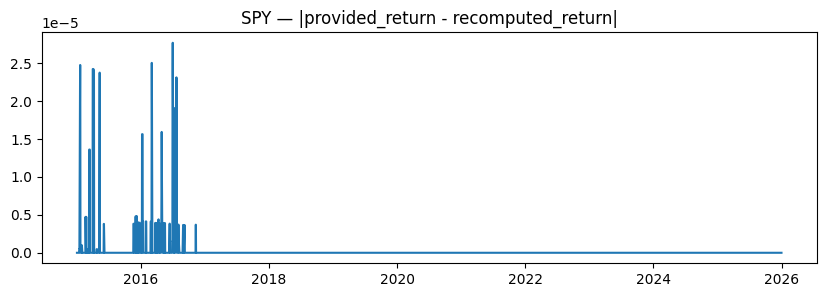

DEBUG: Columns in 'valid' for trailing_vol_annual_decimel_5d_calculated: ['date', 'trailing_vol_annual_decimel_5d_calculated', 'trail_vol_5d_recomp']
SPY trailing vol check — corr(trailing_vol_annual_decimel_5d_calculated, trail_vol_5d_recomp) = 1.0


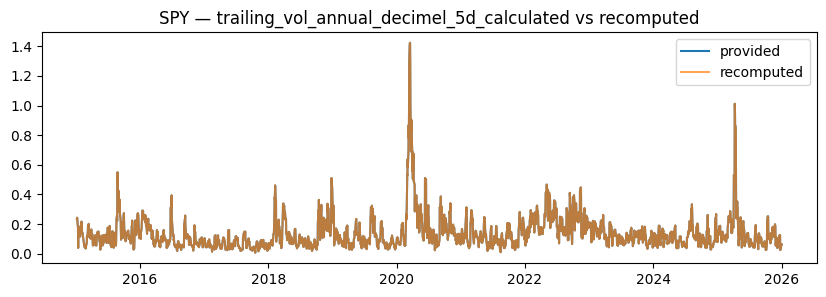

DEBUG: Columns in 'valid' for trailing_vol_annual_decimel_20d_calculated: ['date', 'trailing_vol_annual_decimel_20d_calculated', 'trail_vol_20d_recomp']
SPY trailing vol check — corr(trailing_vol_annual_decimel_20d_calculated, trail_vol_20d_recomp) = 1.0


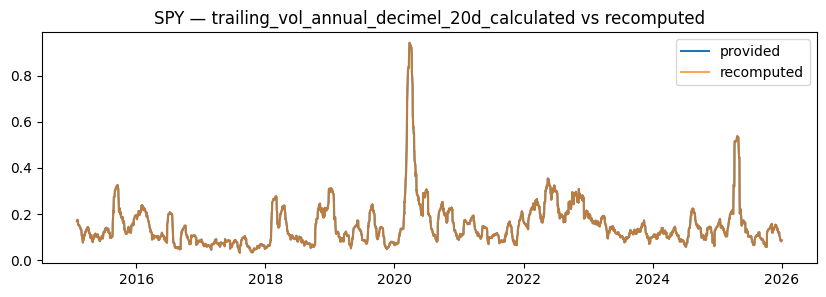

DEBUG: Columns in 'valid' for target: ['date', 'forward_vol_5d_annual_decimel_calculated', 'fwd_vol_5d_recomp']
SPY forward vol (target) check — corr(forward_vol_5d_annual_decimel_calculated, fwd_vol_5d_recomp) = 0.7122


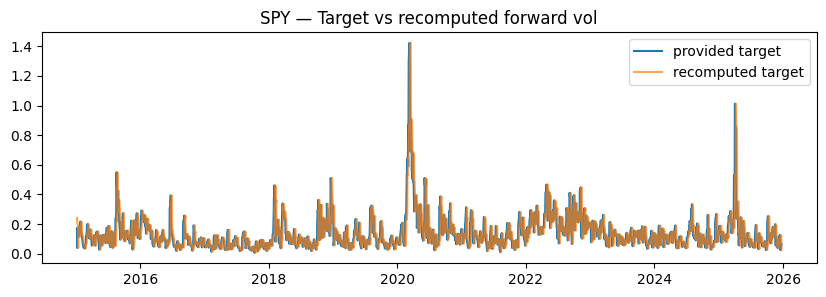

In [ ]:
# Purpose:
# - Recompute key quantities from first principles to detect label/feature misalignment:
#   1) daily_log_return from adj_close
#   2) trailing realized volatility (5d, 20d) from returns
#   3) forward realized volatility label (next 5 trading days) from future returns
#
# These checks catch:
# - wrong sort order
# - accidental look-ahead in features
# - shifted labels

ticker = EDA_SAMPLE_TICKER
d = df[df[TICKER_COL] == ticker].copy().sort_values(DATE_COL)

# 1) Recompute log return from price
if PRICE_COL in d.columns:
    d["ret_recomputed"] = np.log(d[PRICE_COL] / d[PRICE_COL].shift(1))
    if RETURN_COL in d.columns:
        diff = (d[RETURN_COL] - d["ret_recomputed"]).abs()
        print("Return check — mean abs diff:", float(diff.mean()), "| median abs diff:", float(diff.median()))
        plt.figure(figsize=(10,3))
        plt.plot(d[DATE_COL], diff)
        plt.title(f"{ticker} — |provided_return - recomputed_return|")
        plt.show()

# 2) Recompute trailing vol (annualized) from recomputed returns
def trailing_vol_annual(ret_series, window, annualization=252):
    return ret_series.rolling(window=window).std(ddof=1) * math.sqrt(annualization)

if "ret_recomputed" in d.columns:
    d["trail_vol_5d_recomp"] = trailing_vol_annual(d["ret_recomputed"], 5, ANNUALIZATION)
    d["trail_vol_20d_recomp"] = trailing_vol_annual(d["ret_recomputed"], 20, ANNUALIZATION)

    for col, recomp in [
        ("trailing_vol_annual_decimel_5d_calculated", "trail_vol_5d_recomp"),
        ("trailing_vol_annual_decimel_20d_calculated", "trail_vol_20d_recomp"),
    ]:
        if col in d.columns:
            valid = d[[DATE_COL, col, recomp]].dropna()
            # DEBUG: Print columns of 'valid' to diagnose missing DATE_COL
            print(f"DEBUG: Columns in 'valid' for {col}: {valid.columns.tolist()}")
            if len(valid) > 50:
                corr = float(valid[col].corr(valid[recomp]))
                print(f"{ticker} trailing vol check — corr({col}, {recomp}) =", round(corr, 4))
                plt.figure(figsize=(10,3))
                plt.plot(valid[DATE_COL], valid[col], label="provided")
                plt.plot(valid[DATE_COL], valid[recomp], label="recomputed", alpha=0.7)
                plt.title(f"{ticker} — {col} vs recomputed")
                plt.legend()
                plt.show()

# 3) Recompute forward 5d realized vol label (next 5 trading days)
#   At date t, label uses returns at t+1..t+5 (future), annualized.
def forward_vol_annual(ret_series, horizon=5, annualization=252):
    # rolling std over future window: shift(-1) to start at t+1
    fut = ret_series.shift(-1)
    return fut.rolling(window=horizon).std(ddof=1) * math.sqrt(annualization)

if "ret_recomputed" in d.columns:
    d["fwd_vol_5d_recomp"] = forward_vol_annual(d["ret_recomputed"], 5, ANNUALIZATION)
    if TARGET_COL in d.columns:
        valid = d[[DATE_COL, TARGET_COL, "fwd_vol_5d_recomp"]].dropna()
        # DEBUG: Print columns of 'valid' to diagnose missing DATE_COL
        print(f"DEBUG: Columns in 'valid' for target: {valid.columns.tolist()}")
        if len(valid) > 50:
            corr = float(valid[TARGET_COL].corr(valid["fwd_vol_5d_recomp"]))
            print(f"{ticker} forward vol (target) check — corr({TARGET_COL}, fwd_vol_5d_recomp) =", round(corr, 4))
            plt.figure(figsize=(10,3))
            plt.plot(valid[DATE_COL], valid[TARGET_COL], label="provided target")
            plt.plot(valid[DATE_COL], valid["fwd_vol_5d_recomp"], label="recomputed target", alpha=0.7)
            plt.title(f"{ticker} — Target vs recomputed forward vol")
            plt.legend()
            plt.show()

## 11) Simple baselines to beat (persistence using trailing volatility)

In [ ]:
# Purpose:
# - Establish a baseline predictor for forward vol:
#   predict y_t ≈ trailing_vol_5d(t) or trailing_vol_20d(t)
# - Evaluate on a time split (train/val/test).

assert TARGET_COL in df.columns, "Target column missing."

df2 = df.copy()

# Time split masks
train_mask = df2[DATE_COL] <= pd.to_datetime(TRAIN_END)
val_mask   = (df2[DATE_COL] > pd.to_datetime(TRAIN_END)) & (df2[DATE_COL] <= pd.to_datetime(VAL_END))
test_mask  = df2[DATE_COL] > pd.to_datetime(VAL_END)

def rmse(y_true, y_pred):
    v = (y_true - y_pred).dropna()
    return float(np.sqrt(np.mean(v**2)))

def mae(y_true, y_pred):
    v = (y_true - y_pred).dropna()
    return float(np.mean(np.abs(v)))

candidates = [c for c in ["trailing_vol_annual_decimel_5d_calculated", "trailing_vol_annual_decimel_20d_calculated"] if c in df2.columns]
print("Baseline candidate predictors:", candidates)

rows = []
for feat in candidates:
    for split_name, mask in [("train", train_mask), ("val", val_mask), ("test", test_mask)]:
        sub = df2.loc[mask, [TARGET_COL, feat]].dropna()
        if len(sub) == 0:
            continue
        rows.append({
            "baseline_feature": feat,
            "split": split_name,
            "n": len(sub),
            "RMSE": rmse(sub[TARGET_COL], sub[feat]),
            "MAE": mae(sub[TARGET_COL], sub[feat]),
        })

baseline_results = pd.DataFrame(rows).sort_values(["baseline_feature","split"])
display(baseline_results)


Baseline candidate predictors: ['trailing_vol_annual_decimel_5d_calculated', 'trailing_vol_annual_decimel_20d_calculated']


,baseline_feature,split,n,RMSE,MAE
5,trailing_vol_annual_decimel_20d_calculated,test,8820,0.154276,0.097534
3,trailing_vol_annual_decimel_20d_calculated,train,68733,0.132880,0.085128
4,trailing_vol_annual_decimel_20d_calculated,val,18072,0.092954,0.068025
2,trailing_vol_annual_decimel_5d_calculated,test,8820,0.161874,0.102006
0,trailing_vol_annual_decimel_5d_calculated,train,69273,0.140559,0.093647
1,trailing_vol_annual_decimel_5d_calculated,val,18072,0.109418,0.080194


## 12) Optional: Save EDA summary artifacts (tables) to disk

In [ ]:
# Purpose:
# - Save small EDA summary tables (coverage, missingness) for your report/slides.
# - This writes to a local folder relative to the notebook working directory.

EDA_OUTDIR = "eda_outputs"
os.makedirs(EDA_OUTDIR, exist_ok=True)

coverage.to_csv(os.path.join(EDA_OUTDIR, "coverage_by_ticker.csv"))
miss_tbl.to_csv(os.path.join(EDA_OUTDIR, "missingness_by_column.csv"))
macro_check.to_csv(os.path.join(EDA_OUTDIR, "macro_constancy_check.csv"))

print("Wrote EDA outputs to:", EDA_OUTDIR)


Wrote EDA outputs to: eda_outputs
